# Vol Overlay — Signal Research

**Instrument:** SPY (daily bars)
**Signal:** HAR-RV forecasts 20d forward realized vol from 1d, 5d, 21d trailing vol.
**Direction:** Long-only (daily SPY exposure, rebalanced every business day).

**Model selection:** Vol Model Shootout (see macro_strategy/11) compared XGBoost, AR, HAR-RV, Ridge. HAR-RV won: R²=0.51, +0.111 Sharpe vs SPY on 31-year sample.

**Sizing variants compared:**
1. **Symmetric (original)** — exposure = clip(0.15 / pred_vol, 0.25, 1.50). Allows leverage up to 1.5×.
2. **Asymmetric cap** — same formula, clip to [0.25, 1.00]. Never leverage; just cut risk.
3. **Binary defensive** — 0.85 normally, 0.40 when pred_vol > rolling 80th percentile.
4. **Three-state** — 1.00 / 0.85 / 0.40 based on rolling 20/80 percentiles of pred_vol.

**Fees:** Per-day fee scales with turnover (|Δexposure|), not full position rebalance.

**Output:**
- `vol_signal.csv` — predicted_vol + exposures for all 4 variants
- `vol_overlay_trades.csv` — standardized 9-col trades using the winning variant
- `vol_overlay_summary.json` — per-variant stats

## 1. Setup

In [12]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from data.data import fetch_historical_data
from _shared.fees import calculate_fees_pct
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)

In [13]:
# =============================================================================
# CONFIGURATION
# =============================================================================
SYMBOLS     = ["SPY"]
START_DATE  = "2006-01-01"
END_DATE    = "2026-04-01"

STARTING_CAPITAL = 100_000
STRATEGY_NAME    = "Vol Overlay"
SAVE_NAME        = "vol_overlay"

# HAR-RV parameters
FWD_WINDOW     = 20
MIN_TRAIN_DAYS = 504
RETRAIN_EVERY  = 21
EMBARGO_DAYS   = 60

# Sizing — shared
TARGET_VOL = 0.15

# Variant params
SYM_CLIP     = (0.25, 1.50)   # Symmetric
ASYM_CLIP    = (0.25, 1.00)   # Asymmetric cap (no leverage)
BINARY_HIGH  = 0.40           # Binary: low exposure
BINARY_NORM  = 0.85           # Binary: normal exposure
BINARY_PCTL  = 0.80           # Binary: threshold is 80th percentile of pred_vol
THREE_HIGH   = 0.40
THREE_MID    = 0.85
THREE_LOW    = 1.00
THREE_PCTL_HI = 0.80          # Three-state: >80th = high vol = cut
THREE_PCTL_LO = 0.20          # Three-state: <20th = low vol = full 1.0
PCTL_WINDOW  = 504            # 2y rolling for percentile thresholds

## 2. Data Fetching

In [14]:
data_dict = fetch_historical_data(
    SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

spy = data_dict["SPY"].reset_index()
spy["date"] = pd.to_datetime(spy["timestamp"]).dt.tz_localize(None).dt.normalize()
spy = spy.set_index("date").sort_index()
spy["ret"] = spy["close"].pct_change()
spy = spy.dropna(subset=["ret"])

print(f"SPY: {len(spy)} bars, {spy.index[0].date()} → {spy.index[-1].date()}")

Fetching SPY...
  2,575 bars
SPY: 2574 bars, 2016-01-05 → 2026-03-31


## 3. HAR-RV Engine

Predicts 20d forward annualized realized vol from 1d, 5d, 21d trailing vol.
Expanding window, monthly retrain, 60d embargo.

In [15]:
def compute_forward_vol(returns_np, window):
    n = len(returns_np)
    fwd = np.full(n, np.nan)
    for i in range(n - window):
        fwd[i] = np.std(returns_np[i:i+window], ddof=1) * np.sqrt(252)
    return fwd

def build_har_features(returns_np):
    n = len(returns_np)
    X = np.full((n, 3), np.nan)
    for i in range(21, n):
        X[i, 0] = abs(returns_np[i-1]) * np.sqrt(252)
        X[i, 1] = np.std(returns_np[i-5:i], ddof=1) * np.sqrt(252)
        X[i, 2] = np.std(returns_np[i-21:i], ddof=1) * np.sqrt(252)
    return X

def expanding_harrv_predict(X_np, y_np,
                             min_train=MIN_TRAIN_DAYS,
                             retrain_every=RETRAIN_EVERY,
                             embargo=EMBARGO_DAYS):
    from sklearn.linear_model import LinearRegression
    n = len(X_np)
    valid = ~np.isnan(y_np) & ~np.isnan(X_np).any(axis=1)
    pred = np.full(n, np.nan)
    n_models = 0

    for retrain_idx in range(min_train, n, retrain_every):
        train_end = retrain_idx - embargo
        if train_end < 100:
            continue
        train_mask = np.zeros(n, dtype=bool)
        train_mask[:train_end] = True
        train_mask &= valid
        if train_mask.sum() < 50:
            continue
        model = LinearRegression().fit(X_np[train_mask], y_np[train_mask])
        n_models += 1
        pred_end = min(retrain_idx + retrain_every, n)
        for j in range(retrain_idx, pred_end):
            if not np.isnan(X_np[j]).any():
                pred[j] = model.predict(X_np[j:j+1])[0]
    return pred, n_models

In [16]:
returns_np = spy["ret"].values
dates = spy.index.values

fwd_vol = compute_forward_vol(returns_np, FWD_WINDOW)
X_np = build_har_features(returns_np)
pred_vol, n_models = expanding_harrv_predict(X_np, fwd_vol)

both = ~np.isnan(pred_vol) & ~np.isnan(fwd_vol)
from sklearn.metrics import r2_score
r2 = r2_score(fwd_vol[both], pred_vol[both])
corr = np.corrcoef(fwd_vol[both], pred_vol[both])[0, 1]
mae = np.mean(np.abs(fwd_vol[both] - pred_vol[both]))

print(f"Trained {n_models} models, {(~np.isnan(pred_vol)).sum()} OOS predictions")
print(f"OOS R²:   {r2:.4f}")
print(f"OOS Corr: {corr:.4f}")
print(f"OOS MAE:  {mae:.4f}")

Trained 99 models, 2070 OOS predictions
OOS R²:   0.1884
OOS Corr: 0.4699
OOS MAE:  0.0544


## 4. Build 4 Sizing Variants

All four use the same HAR-RV prediction, differ only in how they map `predicted_vol` → `exposure`.

In [17]:
pv = pd.Series(pred_vol, index=pd.DatetimeIndex(dates))

# Variant 1: Symmetric (original)
exp_sym = np.clip(TARGET_VOL / pv, SYM_CLIP[0], SYM_CLIP[1])

# Variant 2: Asymmetric cap (no leverage, just defend)
exp_asym = np.clip(TARGET_VOL / pv, ASYM_CLIP[0], ASYM_CLIP[1])

# Variant 3: Binary defensive — use rolling percentile threshold so it's adaptive
pv_threshold = pv.rolling(PCTL_WINDOW, min_periods=60).quantile(BINARY_PCTL)
exp_bin = pd.Series(BINARY_NORM, index=pv.index)
exp_bin[pv > pv_threshold] = BINARY_HIGH

# Variant 4: Three-state based on rolling 20/80 percentiles
pv_hi = pv.rolling(PCTL_WINDOW, min_periods=60).quantile(THREE_PCTL_HI)
pv_lo = pv.rolling(PCTL_WINDOW, min_periods=60).quantile(THREE_PCTL_LO)
exp_three = pd.Series(THREE_MID, index=pv.index)
exp_three[pv > pv_hi] = THREE_HIGH
exp_three[pv < pv_lo] = THREE_LOW

variants = {
    "symmetric":        exp_sym,
    "asymmetric_cap":   exp_asym,
    "binary_defensive": exp_bin,
    "three_state":      exp_three,
}

# Summary
print("Exposure distribution per variant:\n")
print(f"{'variant':<20} {'mean':>8} {'std':>8} {'min':>8} {'max':>8} {'≤0.5 %':>9} {'≥1.0 %':>9}")
print("-" * 72)
for name, exp in variants.items():
    e = exp.dropna()
    pct_defensive = (e <= 0.5).mean() * 100
    pct_full = (e >= 1.0).mean() * 100
    print(f"{name:<20} {e.mean():>8.3f} {e.std():>8.3f} {e.min():>8.3f} "
          f"{e.max():>8.3f} {pct_defensive:>9.1f} {pct_full:>9.1f}")

Exposure distribution per variant:

variant                  mean      std      min      max    ≤0.5 %    ≥1.0 %
------------------------------------------------------------------------
symmetric               1.126    0.283    0.250    1.500       2.1      67.2
asymmetric_cap          0.933    0.133    0.250    1.000       2.1      67.2
binary_defensive        0.769    0.173    0.400    0.850      18.0       0.0
three_state             0.790    0.189    0.400    1.000      18.0      13.7


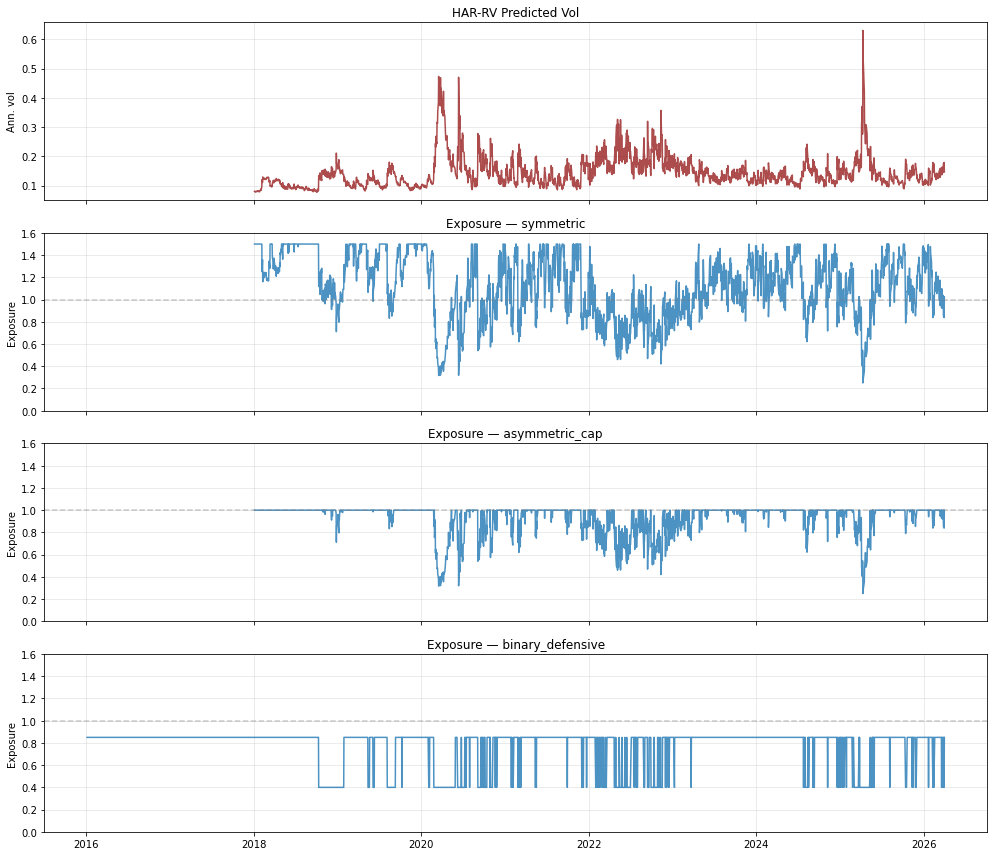

In [18]:
# Plot the 4 exposure schedules
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(pv.index.to_numpy(), pv.to_numpy(), color="darkred", alpha=0.7)
axes[0].set_title("HAR-RV Predicted Vol"); axes[0].set_ylabel("Ann. vol"); axes[0].grid(alpha=0.3)

for ax, (name, exp) in zip(axes[1:], variants.items()):
    ax.plot(exp.index.to_numpy(), exp.to_numpy(), alpha=0.8)
    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.4)
    ax.set_title(f"Exposure — {name}"); ax.set_ylabel("Exposure"); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.6)
plt.tight_layout(); plt.show()

## 5. Backtest Each Variant

Each variant becomes a daily-rebalanced SPY strategy. Fees scale with turnover (|Δexposure|).

In [19]:
def backtest_variant(exposure_series, spy_prices, spy_rets, starting_capital=STARTING_CAPITAL):
    """
    Daily-rebalance SPY at `exposure` each day. Returns gross & net equity + stats + trades.
    Fee per day = |Δexposure| × per_trade_fee. No leverage cost modeled (1x cap for asymmetric).
    """
    # Align
    aligned = pd.DataFrame({"exposure": exposure_series,
                             "close": spy_prices,
                             "ret": spy_rets}).dropna()
    if len(aligned) < 30:
        return None

    idx = aligned.index
    closes = aligned["close"].values
    expos = aligned["exposure"].values

    rows = []
    for i in range(len(aligned) - 1):
        ex_i = expos[i]
        ex_prev = expos[i-1] if i > 0 else 0.0  # assume starting from cash
        turnover = abs(ex_i - ex_prev)

        entry_price = closes[i]
        exit_price = closes[i+1]
        spy_ret_next = (exit_price - entry_price) / entry_price
        pct_return_gross = ex_i * spy_ret_next

        # Per-trade fee scaled by turnover (fraction of position actually traded today)
        base_fee = calculate_fees_pct(entry_price, exit_price, "long")
        fee_pct = base_fee * turnover

        rows.append({
            "entry_time": idx[i], "exit_time": idx[i+1],
            "direction": "long", "instrument": "SPY",
            "entry_price": round(float(entry_price), 4),
            "exit_price":  round(float(exit_price), 4),
            "pct_return_gross": round(float(pct_return_gross), 6),
            "exit_reason": "daily_rebalance",
            "stop_price": np.nan,
            "exposure": round(float(ex_i), 4),
            "turnover": round(float(turnover), 4),
            "fee_pct": round(float(fee_pct), 6),
        })

    trades = pd.DataFrame(rows)
    trades["pct_return_net"] = trades["pct_return_gross"] - trades["fee_pct"]

    r_gross = trades.set_index("entry_time")["pct_return_gross"]
    r_net = trades.set_index("entry_time")["pct_return_net"]
    eq_gross = starting_capital * (1 + r_gross).cumprod()
    eq_net = starting_capital * (1 + r_net).cumprod()
    return {"trades": trades, "r_gross": r_gross, "r_net": r_net,
            "eq_gross": eq_gross, "eq_net": eq_net}

def stats_from_eq(eq, ret, starting_capital=STARTING_CAPITAL):
    daily_r = ret.dropna()
    sharpe = daily_r.mean() / daily_r.std() * np.sqrt(252) if daily_r.std() > 0 else 0
    peak = eq.expanding().max()
    max_dd = ((eq - peak) / peak).min() * 100
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1] / starting_capital) ** (1 / years) - 1) * 100 if years > 0 else 0
    tot = (eq.iloc[-1] / starting_capital - 1) * 100
    return {"total_return": round(tot, 1), "cagr": round(cagr, 2),
            "sharpe": round(sharpe, 2), "max_dd": round(max_dd, 1)}

In [20]:
# Run each variant + baseline SPY B&H
spy_prices = spy["close"]
spy_rets = spy["ret"]

bt = {}
for name, exp in variants.items():
    bt[name] = backtest_variant(exp, spy_prices, spy_rets)

# SPY B&H over the vol-signal period (first valid exposure date onward)
valid_start = min(exp.dropna().index[0] for exp in variants.values())
spy_sub = spy[spy.index >= valid_start]
eq_spy = STARTING_CAPITAL * (1 + spy_sub["ret"]).cumprod()
s_spy = stats_from_eq(eq_spy, spy_sub["ret"])

# Per-variant stats
print(f"Period: {valid_start.date()} → {spy.index[-1].date()}\n")
print(f"{'Strategy':<25} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
print("-" * 65)
print(f"{'SPY Buy & Hold':<25} {s_spy['total_return']:>10,.1f} {s_spy['cagr']:>8.2f} "
      f"{s_spy['sharpe']:>8.2f} {s_spy['max_dd']:>8.1f}")

variant_stats = {}
for name, b in bt.items():
    s_g = stats_from_eq(b["eq_gross"], b["r_gross"])
    s_n = stats_from_eq(b["eq_net"], b["r_net"])
    variant_stats[name] = {"gross": s_g, "net": s_n}
    print(f"{name + ' (gross)':<25} {s_g['total_return']:>10,.1f} {s_g['cagr']:>8.2f} "
          f"{s_g['sharpe']:>8.2f} {s_g['max_dd']:>8.1f}")
    print(f"{name + ' (net)':<25} {s_n['total_return']:>10,.1f} {s_n['cagr']:>8.2f} "
          f"{s_n['sharpe']:>8.2f} {s_n['max_dd']:>8.1f}")

Period: 2016-01-05 → 2026-03-31

Strategy                     TotRet%    CAGR%   Sharpe   MaxDD%
-----------------------------------------------------------------
SPY Buy & Hold                 279.4    13.91     0.83    -33.8
symmetric (gross)              162.8    12.45     0.76    -23.3
symmetric (net)                158.6    12.24     0.75    -23.3
asymmetric_cap (gross)         141.0    11.28     0.78    -21.5
asymmetric_cap (net)           139.5    11.19     0.77    -21.7
binary_defensive (gross)       179.4    10.56     0.94    -17.7
binary_defensive (net)         177.4    10.49     0.93    -17.8
three_state (gross)            179.2    10.56     0.92    -17.7
three_state (net)              176.5    10.45     0.91    -17.8


## 6. Lift vs SPY Buy & Hold

In [21]:
print(f"{'Variant':<20} {'ΔSharpe (net)':>14} {'ΔCAGR':>8} {'ΔMaxDD':>9} {'Avg turnover':>14}")
print("-" * 68)
lift_table = {}
for name, b in bt.items():
    s_n = variant_stats[name]["net"]
    d_sh = s_n["sharpe"] - s_spy["sharpe"]
    d_cagr = s_n["cagr"] - s_spy["cagr"]
    d_dd = s_n["max_dd"] - s_spy["max_dd"]
    avg_to = b["trades"]["turnover"].mean()
    lift_table[name] = {"d_sharpe": d_sh, "d_cagr": d_cagr, "d_dd": d_dd, "avg_turnover": avg_to}
    print(f"{name:<20} {d_sh:>+14.3f} {d_cagr:>+8.2f} {d_dd:>+9.1f} {avg_to:>14.3f}")

Variant               ΔSharpe (net)    ΔCAGR    ΔMaxDD   Avg turnover
--------------------------------------------------------------------
symmetric                    -0.080    -1.67     +10.5          0.097
asymmetric_cap               -0.060    -2.72     +12.1          0.038
binary_defensive             +0.100    -3.42     +16.0          0.035
three_state                  +0.080    -3.46     +16.0          0.049


## 7. Equity Curves — All 4 Variants vs SPY

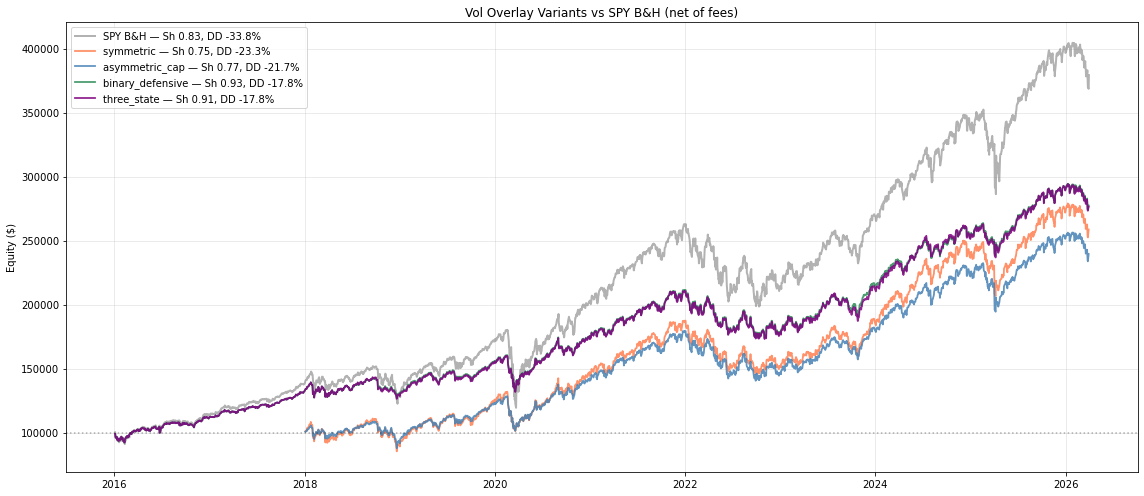

In [22]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(eq_spy.index.to_numpy(), eq_spy.values,
        label=f"SPY B&H — Sh {s_spy['sharpe']}, DD {s_spy['max_dd']}%",
        color="gray", alpha=0.6, linewidth=2)

colors = {"symmetric": "coral", "asymmetric_cap": "steelblue",
          "binary_defensive": "seagreen", "three_state": "purple"}
for name, b in bt.items():
    eq = b["eq_net"]
    s = variant_stats[name]["net"]
    ax.plot(eq.index.to_numpy(), eq.values,
            label=f"{name} — Sh {s['sharpe']}, DD {s['max_dd']}%",
            color=colors[name], linewidth=1.8, alpha=0.85)
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_title("Vol Overlay Variants vs SPY B&H (net of fees)")
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

## 8. Select Winning Variant + Significance

Winner = highest net Sharpe. Run significance tests on its returns.

In [23]:
winner_name = max(variant_stats.keys(), key=lambda n: variant_stats[n]["net"]["sharpe"])
winner_bt = bt[winner_name]
winner_stats = variant_stats[winner_name]
print(f"Winner: {winner_name}")
print(f"  Net Sharpe: {winner_stats['net']['sharpe']} (SPY B&H: {s_spy['sharpe']}, lift: {winner_stats['net']['sharpe'] - s_spy['sharpe']:+.3f})")
print(f"  Net CAGR:   {winner_stats['net']['cagr']}% (SPY: {s_spy['cagr']}%)")
print(f"  Net MaxDD:  {winner_stats['net']['max_dd']}% (SPY: {s_spy['max_dd']}%)")

# Significance
sig_df = pd.DataFrame({
    "net_pnl": winner_bt["r_net"].values,
    "equity_before": 1.0,
    "position": "long",
    "direction": "long",
})
report = full_significance_report(sig_df, strategy_name=f"{STRATEGY_NAME} ({winner_name})")
print_significance_report(report)

Winner: binary_defensive
  Net Sharpe: 0.93 (SPY B&H: 0.83, lift: +0.100)
  Net CAGR:   10.49% (SPY: 13.91%)
  Net MaxDD:  -17.8% (SPY: -33.8%)

STATISTICAL SIGNIFICANCE — Vol Overlay (binary_defensive)

1. t-test (returns > 0)
   Mean return:  0.0423% per trade
   t-statistic:  2.9785
   p-value:      0.001462
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.9323
   95% CI:            [0.3176, 1.5515]
   % below zero:      0.11%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.9323
   p-value:           0.0019
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 9. Save Outputs

In [24]:
import os, json
os.makedirs("results", exist_ok=True)

# vol_signal.csv: predicted_vol + exposure for ALL variants (plus `exposure` column = winner)
vol_signal_df = pd.DataFrame({"predicted_vol": pv})
for name, exp in variants.items():
    vol_signal_df[f"exposure_{name}"] = exp
vol_signal_df["exposure"] = variants[winner_name]  # canonical column = winner
vol_signal_df = vol_signal_df.dropna(subset=["predicted_vol"])
vol_signal_df.to_csv("results/vol_signal.csv")
print(f"Saved vol_signal.csv ({len(vol_signal_df)} rows, winner='{winner_name}')")

# Standardized trades from the winning variant
std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
winner_trades = winner_bt["trades"]
winner_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(winner_trades)} trades → results/{SAVE_NAME}_trades.csv")

# Summary JSON with all variants
summary = {
    "strategy": STRATEGY_NAME,
    "instruments": SYMBOLS,
    "portfolio": "long_term",
    "period": f"{valid_start.date()} → {spy.index[-1].date()}",
    "model": "HAR-RV",
    "winner": winner_name,
    "oos_model_stats": {"r2": float(r2), "corr": float(corr), "mae": float(mae)},
    "spy_bh": s_spy,
    "variants": {name: {"gross": variant_stats[name]["gross"],
                         "net":   variant_stats[name]["net"],
                         "lift_net_sharpe": round(variant_stats[name]["net"]["sharpe"] - s_spy["sharpe"], 3),
                         "avg_turnover": round(float(bt[name]["trades"]["turnover"].mean()), 4)}
                  for name in variants},
    "significance_winner": {
        "sharpe": report["bootstrap"]["observed_sharpe"],
        "verdict": report["verdict"],
        "tests_passed": report["tests_passed"],
    },
    "params": {
        "fwd_window": FWD_WINDOW, "target_vol": TARGET_VOL,
        "sym_clip": list(SYM_CLIP), "asym_clip": list(ASYM_CLIP),
        "binary_high": BINARY_HIGH, "binary_norm": BINARY_NORM, "binary_pctl": BINARY_PCTL,
        "three_high": THREE_HIGH, "three_mid": THREE_MID, "three_low": THREE_LOW,
        "three_pctl_hi": THREE_PCTL_HI, "three_pctl_lo": THREE_PCTL_LO,
        "pctl_window": PCTL_WINDOW,
    },
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary → results/{SAVE_NAME}_summary.json")
print(f"\nNext: run vol_overlay_Implementation.ipynb")

Saved vol_signal.csv (2070 rows, winner='binary_defensive')
Saved 2573 trades → results/vol_overlay_trades.csv
Saved summary → results/vol_overlay_summary.json

Next: run vol_overlay_Implementation.ipynb
